## Contrastive pre-training

Here, we will try the SimCLR method.

[1] T. Chen et al. “A Simple Framework for Contrastive Learning of Visual Representations”. In: ICML. 2020.


In [1]:
import os
import shutil
import yaml
import logging
import sys
import zipfile
from copy import deepcopy


## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

## Torchvision
import torchvision
from torchvision import transforms
from torch.utils.data import random_split
from torchvision.datasets import STL10, PCAM
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn

## Plot Options
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import seaborn as sns
plt.set_cmap("cividis")
%matplotlib inline
sns.set_theme()

## SKlearn
from sklearn.linear_model import LogisticRegression


# In this notebook, we use data loaders with heavier computational processing. It is recommended to use as many
# workers as possible in a data loader, which corresponds to the number of CPU cores
NUM_WORKERS = os.cpu_count()
print("Number of workers:", NUM_WORKERS)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.determinstic = True
torch.backends.cudnn.benchmark = False

# For reproducibility
np.random.seed(666)
torch.manual_seed(666)


try:
  import google.colab
  IN_COLAB = True
  !pip install gdown==4.6.0 # with the following versions, there is an error
  import gdown
except:
  IN_COLAB = False

Hfactory=False # put equal to True, if you are using HFactory
if Hfactory:
    !pip install gdown==4.6.0 # with the following versions, there is an error
    !pip uninstall -y h5py
    !pip install h5py
    import h5py


Number of workers: 2


<Figure size 640x480 with 0 Axes>

In [2]:
print("Using torch", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.")
elif torch.cuda.is_available():
    device = torch.device("cuda:0") # we use one GPU, the first one
    print ("CUDA device found.")
else:
   device = torch.device("cpu")
   print('No MPS or CUDA has been found. PyTorch will use CPU.')

Using torch 2.5.1+cu124
CUDA device found.


### Data Augmentation for Contrastive Learning

One of the key points of SimCLR is the choice of the augmentation strategy. It composes many different geometric and iconographic transformations.
We can implement them very efficiently and easily using the Dataset object of Pytorch.

Since in SimCLR authors use 2 views, we do the same here. Please note that we could use more positives

The transformations used are: (figure credit - [Ting Chen and Geoffrey Hinton](https://ai.googleblog.com/2020/04/advancing-self-supervised-and-semi.html)):

<center width="100%"><img src="https://github.com/Lightning-AI/lightning-tutorials/raw/main/course_UvA-DL/13-contrastive-learning/simclr_data_augmentations.jpg" width="800px" style="padding-top: 10px; padding-bottom: 10px"></center>

When using ImageNet-derived datasets, the two most important transformations are: crop-and-resize, and color distortion.
Interestingly, they need to be used together since, when combining randomly cropping and resizing, we might have two situations: (a) cropped image A provides a local view of cropped image B, or (b) cropped images C and D show neighboring views of the same image (figure credit - [Ting Chen and Geoffrey Hinton](https://ai.googleblog.com/2020/04/advancing-self-supervised-and-semi.html)).

<center width="100%"><img src="https://github.com/Lightning-AI/lightning-tutorials/raw/main/course_UvA-DL/13-contrastive-learning/crop_views.svg" width="400px" style="padding-top: 20px; padding-bottom: 0px"></center>

While situation (a) requires the model to learn some sort of scale invariance to make crops A and B similar in the representation space, situation (b) is more challenging since the model needs to recognize an object beyond its limited view.
However, the network can use the color information (color histograms) to create a useless link between the two patches, without learning generalizable high-level representations. For instance, it could focus on the color of the fur of the dog and on the color of the background to understand that the two patches belong to the same image. That's why, we need to compose crop-and-resize and color distortion.

**Question**: Create a Pytorch class of transformations (transforms.Compose) where you apply the following augmentations:
- Resize an Crop
- Horizontal Flip
- Color jittering
- Gray scale changes
- Gaussian Blur

Hint: all functions have already been implemented and can be found here: https://pytorch.org/vision/0.9/transforms.html

Alternatively, you can also use [albumentations](https://albumentations.ai/) by simply adding:

`import albumentations as A`

`from albumentations.pytorch.transforms import ToTensorV2`

In [3]:
import torchvision.transforms as transforms

class ContrastiveTransformations:
    def __init__(self, img_size, s=1):
        self.data_transform = transforms.Compose([
            transforms.RandomResizedCrop(size=img_size, scale=(0.2, 1.0)),  # Resize and Crop
            transforms.RandomHorizontalFlip(p=0.5),  # Horizontal Flip
            transforms.ColorJitter(brightness=0.8 * s, contrast=0.8 * s, saturation=0.8 * s, hue=0.2 * s),  # Color Jittering
            transforms.RandomGrayscale(p=0.2),  # Grayscale changes
            transforms.GaussianBlur(kernel_size=int(0.1 * img_size)),  # Gaussian Blur
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet Normalization
        ])

    def __call__(self, x):
        return self.data_transform(x), self.data_transform(x)  # Return two augmented views


In [4]:
# simple transformation to use networks pre-trained on ImageNet
img_transforms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

**Question**: What's the difference between `ContrastiveTransformations` and `img_transforms` ? Look inside the functions and their outputs...


**ContrastiveTransformations** applies strong augmentations (crop, flip, color jitter, blur, grayscale) and outputs two augmented images for learning invariant features. **img_transforms** performs only normalization, outputting a single image for inference.


In [5]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
if IN_COLAB:
    #data_directory="./" # decomment it if you do NOT use Google Drive
    data_directory="/content/drive/MyDrive/TP/"  # decomment it if you USE Google Drive and copy/paste the path to your Google Drive
elif Hfactory:
    data_directory="./"
else:
    data_directory="/Users/pgori/Nextcloud/Lavoro/Corsi/MachineLearning/DataSets-TP/" # copy/paste the path of the folder with STL dataset in your computer

We create unlabeled, training and test Datasets.
Please be careful since we use two different transformations, one for the unlabelled part and one for train/test set.

In [7]:
unlabeled_dataset_2viewsCon = STL10(root=data_directory+"data", split="unlabeled", download=True, transform=ContrastiveTransformations(96))
train_dataset = STL10(root=data_directory+"data", split="train", download=True, transform=img_transforms)
# just to show the effect of the augmentations and the classes
train_dataset_2viewsCon = STL10(root=data_directory+"data", split="train", download=True, transform=ContrastiveTransformations(96))
test_dataset = STL10(root=data_directory+"data", split="test", download=True, transform=img_transforms)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


In [8]:
# To check the classes in STL10
classes=unlabeled_dataset_2viewsCon.classes
print(classes)
print('Number images in Unlabeled dataset:' ,len(unlabeled_dataset_2viewsCon))
print(unlabeled_dataset_2viewsCon[0][0][0].shape) # this is one image (the first of the 2-views tuple)

# Train dataset
labels=train_dataset.labels # retrieve label of each sample
print('Number images in Train dataset:' , len(train_dataset)) # retrieve length of dataset
print(train_dataset[3][0].shape) # this is one image

#Test dataset
print('Number images in Test dataset:' ,len(test_dataset))
print(test_dataset[0][0].shape) # this is one image

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Number images in Unlabeled dataset: 100000
torch.Size([3, 96, 96])
Number images in Train dataset: 5000
torch.Size([3, 96, 96])
Number images in Test dataset: 8000
torch.Size([3, 96, 96])


The Unlabeled dataset contains 100k images. Here, to limit memory requirement, we will use 10% of the data.

In [9]:
sizeUnlabelled=5000

unlabeled_dataset_2viewsCon_red,rest = random_split(unlabeled_dataset_2viewsCon, [sizeUnlabelled, len(unlabeled_dataset_2viewsCon)-sizeUnlabelled])
len(unlabeled_dataset_2viewsCon_red)
del unlabeled_dataset_2viewsCon # free memory

We can also create a function to visualize the views of each sample, based on the chosen augmentation strategy.

In [10]:
def imshowSTL102views(datasetOrig,datasetTransform,rows=5,figsize=(8, 15)):
    fig = plt.figure(figsize=figsize)
    for i in range(1, 3*(rows-1)+2,3):
      imgOrig = datasetOrig[i][0]
      img1=datasetTransform[i][0][0]
      img2=datasetTransform[i][0][1]

      #REMOVE NORMALIZATION
      mean = torch.tensor([0.485, 0.456, 0.406])
      std = torch.tensor([0.229, 0.224, 0.225])
      unnormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())
      # Clip values to range [0,1] -> possible rounding errors during normalization
      imgOrig = np.clip(unnormalize(imgOrig).numpy(),0,1)
      img1 = np.clip(unnormalize(img1).numpy(),0,1)
      img2 = np.clip(unnormalize(img2).numpy(),0,1)

      label = datasetOrig[i][1]
      fig.add_subplot(rows, 3, i)
      plt.title(datasetOrig.classes[label]+ ' , original')
      plt.imshow(np.transpose(imgOrig, (1, 2, 0)))
      plt.axis("off")
      fig.add_subplot(rows, 3, i+1)
      plt.title(datasetOrig.classes[label] + ' , 1st view')
      plt.imshow(np.transpose(img1, (1, 2, 0)))
      plt.axis("off")
      fig.add_subplot(rows, 3, i+2)
      plt.title(datasetOrig.classes[label] + ' , 2nd view')
      plt.imshow(np.transpose(img2, (1, 2, 0)))
      plt.axis("off")
    plt.show()

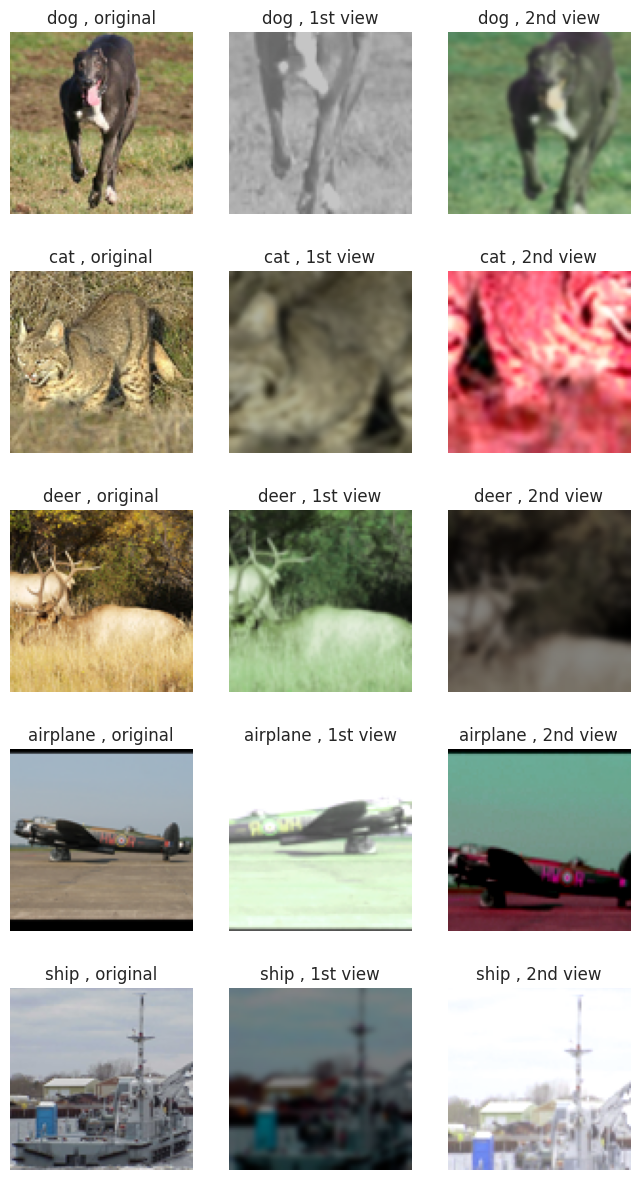

In [11]:
imshowSTL102views(train_dataset,train_dataset_2viewsCon)

In [12]:
del train_dataset_2viewsCon # To free memory

Here, it's the most important part of the code.

I remind you that the Siamese architecture of SimCLR is: (figure credit - [Ting Chen et al. ](https://arxiv.org/abs/2006.10029)):

<center width="100%"><img src="https://github.com/Lightning-AI/lightning-tutorials/raw/main/course_UvA-DL/13-contrastive-learning/simclr_network_setup.svg" width="350px"></center>

The employed loss is the InfoNCE loss:
$$
\ell_{i,j}=-\log \frac{\exp(\text{sim}(z_i,z_j)/\tau)}{\sum_{k=1}^{2N}\mathbb{1}_{[k\neq i]}\exp(\text{sim}(z_i,z_k)/\tau)}=-\text{sim}(z_i,z_j)/\tau+\log\left[\sum_{k=1}^{2N}\mathbb{1}_{[k\neq i]}\exp(\text{sim}(z_i,z_k)/\tau)\right]
$$
where $\tau$ is the temperature and the similarity measure is the cosine similarity:
$$
\text{sim}(z_i,z_j) = \frac{z_i^\top \cdot z_j}{||z_i||\cdot||z_j||}
$$
The maximum cosine similarity possible is $1$, while the minimum is $-1$.

After training, we will remove the projection head $g(\cdot)$, and use $f(\cdot)$ as a pretrained feature extractor.


**Question**: Comment the code where you see **XXXXXXXXXXXXXXXXXX** explaining in details what the code is doing.

PS: if you are using a MacBook, you might have issues with multiprocessing. In that case, please use Google Colab.

In [21]:
class SimCLR():
    def __init__(self, model, optimizer, scheduler, device, batch_size, temperature, epochs):
        self.device = device
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.criterion = torch.nn.CrossEntropyLoss().to(self.device)
        self.temperature = temperature
        self.batch_size = batch_size
        self.epochs = epochs

    def info_nce_loss(self, features):
        # Create labels for positive pairs: Each sample in the batch has an augmented counterpart.
        labels = torch.cat([torch.arange(self.batch_size) for i in range(2)], dim=0)
        labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()  # Create a similarity mask
        labels = labels.to(self.device)

        # Normalize feature vectors to ensure cosine similarity calculation is correct.
        features = F.normalize(features, dim=1)

        # Compute cosine similarity matrix between all feature vectors.
        similarity_matrix = torch.matmul(features, features.T)

        # Remove self-comparison (diagonal elements), since they trivially have max similarity.
        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(self.device)
        labels = labels[~mask].view(labels.shape[0], -1)
        similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)

        # Extract similarity scores for positive pairs (same image under different augmentations).
        positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)

        # Extract similarity scores for negative pairs (different images in the batch).
        negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)

        # Concatenate positive and negative similarities into logits for InfoNCE computation.
        logits = torch.cat([positives, negatives], dim=1)
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(self.device)  # Positive samples at index 0

        # Scale the logits by the temperature parameter to adjust the contrastive strength.
        logits = logits / self.temperature
        return logits, labels

    def train(self, train_loader, use_amp=False):
        # Initialize GradScaler for mixed-precision training (if enabled)
        scaler = GradScaler(enabled=use_amp) if torch.cuda.is_available() else None

        n_iter = 0
        print("Start SimCLR training for {} epochs.".format(self.epochs))

        for epoch_counter in range(self.epochs):
            for images,_ in tqdm(train_loader):
                # Concatenate images from different augmentations into a single batch.
                images = torch.cat(images, dim=0)
                images = images.to(self.device)

                if torch.cuda.is_available() and use_amp:
                    # Mixed precision training with automatic casting to FP16 for efficiency.
                    with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                        features = self.model(images)
                        logits, labels = self.info_nce_loss(features)
                        loss = self.criterion(logits, labels)
                else:
                    # Standard precision training without mixed-precision acceleration.
                    features = self.model(images)
                    logits, labels = self.info_nce_loss(features)
                    loss = self.criterion(logits, labels)

                self.optimizer.zero_grad()

                if scaler is not None:
                    # Backpropagation with gradient scaling (for mixed precision stability).
                    scaler.scale(loss).backward()
                    scaler.step(self.optimizer)
                    scaler.update()
                else:
                    # Standard backpropagation.
                    loss.backward()
                    self.optimizer.step()

                n_iter += 1

            # Step the scheduler to adjust learning rate after a certain number of epochs.
            if epoch_counter >= 5:
                self.scheduler.step()

            print('Epoch: {}, Average loss: {:.4f}, lr: {:.4f}'.format(
                epoch_counter, loss / len(train_loader.dataset), self.scheduler.get_last_lr()[0]))

        print("Training has finished.")


As before, we use a DataLoader.

DataLoader wraps an iterable around the Dataset to enable easy access to the samples. The Dataset retrieves our dataset features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python multiprocessing to speed up data retrieval. DataLoader is an iterable that abstracts this complexity for us in an easy API.


In [22]:
bs = 300 # choose an appropriate batch size depending on the computational resources

train_unlabelled_loader = DataLoader(dataset=unlabeled_dataset_2viewsCon_red, batch_size=bs, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, persistent_workers=True)

Here we define the hyper-parameters, optimization, scheduler and launch the training.

**Question**: complete the code where you see XXXXX.

As model for $f()$, use a ResnNet18 not-pretrained. Remember that the model ResNet18 has already a Linear Layer at the end (fc) which can be written as $Wf(x)$. You can also change the `out_features` of the fc by adding the option `num_classes=XXXX` while loading the model.

 As projection head, use the one from the article

 $$ g(f(x))=W^a \sigma (W^b f(x))$$

 where $\sigma$ is a Relu non-linearity.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

max_epochs = 2
lr = 0.003
wd = 1e-4
temperature = 0.07
g_dim = 128  # The output dimension of the projection head

# Ensure that you are using GPU and all CPU workers
print("Device:", device)

# Encoder f
f = models.resnet18(pretrained=False)  # Wf()

# Projection head g()
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, in_dim)  # Wb
        self.fc2 = nn.Linear(in_dim, out_dim)  # Wa

    def forward(self, x):
        x = F.relu(self.fc1(x))  # σ(Wb f(x))
        x = self.fc2(x)  # Wa σ(Wb f(x))
        return x

g = ProjectionHead(f.fc.in_features, g_dim)

# Replace the final fully connected layer of ResNet18 with the projection head
g = ProjectionHead(f.fc.in_features, g_dim)
f.fc = g

optimizer = torch.optim.Adam(f.parameters(), lr=lr, weight_decay=wd)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_unlabelled_loader), eta_min=0, last_epoch=-1)


Device: cuda:0


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [24]:
f

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [25]:
max_epochs=2

In [26]:
simclr = SimCLR(model=f, optimizer=optimizer, scheduler=scheduler, device=device, batch_size=bs, temperature=temperature, epochs=max_epochs)

if torch.cuda.is_available():
    simclr.train(train_unlabelled_loader, use_amp = True)
else:
    simclr.train(train_unlabelled_loader, use_amp = False)

# save model checkpoints
os.makedirs('models/', exist_ok=True)
filename = 'models/resnet18_simclr_2epochs_stl10.pth.tar'
torch.save({
                'epoch': max_epochs,
                'state_dict': simclr.model.state_dict()
            }, filename)

<ipython-input-21-84e247519485>:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp) if torch.cuda.is_available() else None


Start SimCLR training for 2 epochs.


100%|██████████| 16/16 [00:42<00:00,  2.63s/it]


Epoch: 0, Average loss: 0.0013, lr: 0.0030


100%|██████████| 16/16 [00:35<00:00,  2.25s/it]

Epoch: 1, Average loss: 0.0013, lr: 0.0030
Training has finished.


To continue, you can use a model that I have already pre-trained for 100 epochs.

In [27]:
model_path = 'models/resnet18_simclr_50epochs_stl10.pth.tar'

if os.path.isfile(data_directory+model_path):
    print("pre-trained model already downloaded")
else:
    print("downloading the pre-trained model")
    os.makedirs(data_directory+'models/', exist_ok=True)
    file_url = 'https://drive.google.com/uc?id=13_ZueA9mqh17GvYVkfU_Yokg3z065rKG'
    gdown.download(file_url, data_directory+model_path)


# Load checkpoint file of already trained model
checkpoint = torch.load(data_directory+model_path, map_location=torch.device(device))

# Load Model parameters and set it into eval mode
model_download = models.resnet18(weights=None) # we will only use f and not g
model_download.load_state_dict(checkpoint['state_dict'], strict=False)

epoch = checkpoint['epoch']


pre-trained model already downloaded


<ipython-input-27-0eb85eecf3d8>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(data_directory+model_path, map_location=torch.device(device))


As previously explained, we can now use $f()$ to encode the samples discarding $g()$.

**Question** How can you discard the projection ? Complete the code.

In [28]:
import torch.nn as nn
from copy import deepcopy
from torch.utils import data
from tqdm import tqdm

@torch.no_grad()
def prepare_data_features(model, dataset, batchsize, device):
    # Prepare model
    network = deepcopy(model)

    # Discard the projection (fc layer)
    network.fc = nn.Identity()

    network.eval()
    network.to(device)

    # Encode all images
    data_loader = data.DataLoader(dataset, batch_size=batchsize, num_workers=4, shuffle=False, drop_last=False)

    feats, labels = [], []
    for batch_imgs, batch_labels in tqdm(data_loader):
        batch_imgs = batch_imgs.to(device)
        batch_feats = network(batch_imgs)
        feats.append(batch_feats.detach().cpu())
        labels.append(batch_labels)

    feats = torch.cat(feats, dim=0)
    labels = torch.cat(labels, dim=0)

    # Sort images by labels
    labels, idxs = labels.sort()
    feats = feats[idxs]

    return data.TensorDataset(feats, labels), [feats.numpy(), labels.numpy()]


We can use either the trained model or the downloaded model and encode the train and test images.

In [29]:
#modelTrained=simclr.model
modelTrained=model_download
trainloader, [train_feats, train_labels] = prepare_data_features(modelTrained, train_dataset, batchsize=256, device=device)
testloader, [test_feats, test_labels] = prepare_data_features(modelTrained, test_dataset, batchsize=256, device=device)
print(train_feats.shape, train_labels.shape)
print(test_feats.shape, test_labels.shape)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 32/32 [00:05<00:00,  6.22it/s]

(5000, 512) (5000,)
(8000, 512) (8000,)


**Linear Probe**:  we train a logistic regression on the train dataset and evaluate it on the test dataset. This is called Linear Probe.

**Question**: compute the training and test errore using a logistic regression where you are free to use a regularization.

In [30]:
# compute linear probe results
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Train logistic regression model
clf = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, multi_class='multinomial')
clf.fit(train_feats, train_labels)

# Predict on train and test sets
train_preds = clf.predict(train_feats)
test_preds = clf.predict(test_feats)

# Compute Error Rates
train_error = 1 - accuracy_score(train_labels, train_preds)
test_error = 1 - accuracy_score(test_labels, test_preds)

# Display Errors
print(f"Training Error: {train_error * 100:.2f}%")
print(f"Test Error: {test_error * 100:.2f}%")



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Error: 38.10%
Test Error: 49.99%


What if we simply used it a pre-trained model on ImageNet ? ...

**Question**: use the previous function `prepare_data_features` with a resnet18 pre-trained on Imagenet and compute the Linear Probe as before.

In [31]:
import torch
import torchvision.models as models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load a pre-trained ResNet18 on ImageNet
resnet_imagenet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Remove the classification layer to use only f()
resnet_imagenet.fc = torch.nn.Identity()

# Extract features from train and test datasets
trainloader, [train_feats, train_labels] = prepare_data_features(resnet_imagenet, train_dataset, batchsize=256, device=device)
testloader, [test_feats, test_labels] = prepare_data_features(resnet_imagenet, test_dataset, batchsize=256, device=device)

# Train logistic regression model
clf = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, multi_class='multinomial')
clf.fit(train_feats, train_labels)

# Predict on train and test sets
train_preds = clf.predict(train_feats)
test_preds = clf.predict(test_feats)

# Compute accuracy
train_acc = accuracy_score(train_labels, train_preds)
test_acc = accuracy_score(test_labels, test_preds)

# Compute error (1 - accuracy)
train_error = 1 - train_acc
test_error = 1 - test_acc

print(f"Train Accuracy (ImageNet ResNet18): {train_acc:.4f}")
print(f"Test Accuracy (ImageNet ResNet18): {test_acc:.4f}")
print(f"Train Error (ImageNet ResNet18): {train_error:.4f}")
print(f"Test Error (ImageNet ResNet18): {test_error:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 32/32 [00:10<00:00,  3.10it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy (ImageNet ResNet18): 1.0000
Test Accuracy (ImageNet ResNet18): 0.8629
Train Error (ImageNet ResNet18): 0.0000
Test Error (ImageNet ResNet18): 0.1371


**Question**: is the result better ? Why in your opinion ? What could you do to improve the method with the worst result ?





> The ImageNet-pretrained ResNet18 performs much better than the SimCLR model because it was trained with supervised learning on a massive labeled dataset, leading to feature representations optimized for classification. In contrast, SimCLR learns instance discrimination through self-supervised contrastive learning, which may not align perfectly with classification tasks, especially on smaller datasets.

>  To improve SimCLR, one could train on a larger dataset, use a deeper network, refine the projection head, or fine-tune the model on labeled data





To go further, you could use one of the datasets present in Med Mnist (https://medmnist.com/). These are real but rescaled images. Small images allow the training of DL models on small GPU but we loose resolution and thus clinically relevant information.

Otherwise, you could use the PatchCamelyon dataset (https://www.kaggle.com/datasets/andrewmvd/metastatic-tissue-classification-patchcamelyon), which comprises real and large images.

The PatchCamelyon benchmark is a image classification dataset. It consists of 327.680 color images (96 x 96px) extracted from histopathologic scans of lymph node sections. Each image is annoted with a binary label indicating presence of metastatic tissue.

You can donwload it from pytorch vision or, if you are using Google Colab, directly from our Google drive. The pytorch version needs to be unzipped and there is not enough RAM memory in the Google Colab servers...

Please do not change the following code.

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/metastatic-tissue-classification-patchcamelyon")

print("Path to dataset files:", path)

KeyboardInterrupt: 

In [36]:
os.makedirs(data_directory+"data/pcam", exist_ok=True)

# Download the Train set
file_url = 'https://drive.google.com/uc?id=1ipIG12YWag54v2_2JIyfPiZDN0Eu3IjB'
train_path = 'camelyonpatch_level_2_split_train_x.h5'
if os.path.isfile(data_directory+"data/pcam/"+train_path):
    print("training set already downloaded")
else:
    print("downloading training set")
    gdown.download(file_url, data_directory+"data/pcam/"+train_path, quiet=False)

# Download Valid set
file_url = 'https://drive.google.com/uc?id=1emdhTV8J8Pv-SjKSoMzE_SbT04Ik2yUm'
valid_path = 'camelyonpatch_level_2_split_valid_x.h5'
if os.path.isfile(data_directory+"data/pcam/"+valid_path):
    print("validation set already downloaded")
else:
    print("downloading validation set")
    gdown.download(file_url, data_directory+"data/pcam/"+valid_path, quiet=False)

# Download Test set
file_url = 'https://drive.google.com/uc?id=1dkeFapKSKm-wUtf9zicxiSHWIS0uxv8Z'
test_path = 'camelyonpatch_level_2_split_test_x.h5'
if os.path.isfile(data_directory+"data/pcam/"+test_path):
    print("test set already downloaded")
else:
    print("downloading test set")
    gdown.download(file_url, data_directory+"data/pcam/"+test_path, quiet=False)

# Download the labels
file_url = 'https://drive.google.com/uc?id=10ftBj2ZiiDESTsANdF-v8oh4NieinYPP'
labels_path = 'Label.zip'
if os.path.isfile(data_directory+"data/pcam/camelyonpatch_level_2_split_test_y.h5"):
    print("Labels already downloaded")
else:
    print("downloading labels")
    gdown.download(file_url, data_directory+"data/pcam/"+labels_path, quiet=False)
    # Unzip and move to data directory
    with zipfile.ZipFile(data_directory+"data/pcam/"+labels_path, 'r') as zip_ref:
        zip_ref.extractall(data_directory+"data/pcam/")
    # Moving files
    os.rename(data_directory+"data/pcam/Labels/camelyonpatch_level_2_split_test_y.h5", data_directory+"data/pcam/camelyonpatch_level_2_split_test_y.h5")
    os.rename(data_directory+"data/pcam/Labels/camelyonpatch_level_2_split_train_y.h5", data_directory+"data/pcam/camelyonpatch_level_2_split_train_y.h5")
    os.rename(data_directory+"data/pcam/Labels/camelyonpatch_level_2_split_valid_y.h5", data_directory+"data/pcam/camelyonpatch_level_2_split_valid_y.h5")
    # Cleaning
    os.remove(data_directory+"data/pcam/"+labels_path)
    os.rmdir(data_directory+"data/pcam/Labels")

downloading training set
Access denied with the following error:
downloading validation set



 	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator. 

You may still be able to access the file from the browser:

	 https://drive.google.com/uc?id=1ipIG12YWag54v2_2JIyfPiZDN0Eu3IjB 



Access denied with the following error:
downloading test set



 	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator. 

You may still be able to access the file from the browser:

	 https://drive.google.com/uc?id=1emdhTV8J8Pv-SjKSoMzE_SbT04Ik2yUm 



Access denied with the following error:
downloading labels



 	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator. 

You may still be able to access the file from the browser:

	 https://drive.google.com/uc?id=1dkeFapKSKm-wUtf9zicxiSHWIS0uxv8Z 



Access denied with the following error:



 	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses. 

You may still be able to access the file from the browser:

	 https://drive.google.com/uc?id=10ftBj2ZiiDESTsANdF-v8oh4NieinYPP 



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/TP/data/pcam/Label.zip'

Now you can load it using the PCAM Dataset and DataLoader (keep download as False since you have already downloaded the data)

In the following, you will use the training split as if it was unlabeled, thus for the self-supervised part, then the val split as if it was the training set and the test split as test set.

In [ ]:
img_size=96
bs = 128

# ### PCAM Dataset

PCAM_unlabeled_dataset = PCAM(root=data_directory+"data", download=False, split='train', transform=ContrastiveTransformations(img_size))
PCAM_train_dataset = PCAM(root=data_directory+"data", download=False, split='val', transform=transforms.ToTensor())
PCAM_test_dataset = PCAM(root=data_directory+"data", download=False, split='test', transform=transforms.ToTensor())
print('There are: ', len(PCAM_unlabeled_dataset), 'training images; ', len(PCAM_train_dataset), ' validation images; and ', len(PCAM_test_dataset), ' test images')


PCAM_unlabeled_loader = DataLoader(dataset=PCAM_unlabeled_dataset, batch_size=bs, num_workers=NUM_WORKERS, shuffle=True)
PCAM_train_loader = DataLoader(PCAM_train_dataset, batch_size=bs)
PCAM_test_loader = DataLoader(PCAM_test_dataset, batch_size=bs)


In [ ]:
data_directory

In [ ]:
data_directory

We can visualize the images as before

In [ ]:
# Visualize some examples
NUM_IMAGES = 12
PCAM_images = torch.stack([PCAM_train_dataset[np.random.randint(len(PCAM_train_dataset))][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(PCAM_images, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the PCAM dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

**Question**: As before, train the SimCLR algorithm on the unlabeled set and then train and test the Linear Probe.

This time, you can use the ResNet-18 pre-trained on ImageNet and train it for just 10 epochs.
If you want to speed up the computations (a bit) you can also reduce the size of the images


In [ ]:
max_epochs=20
lr=0.003
wd=1e-4
temperature=0.07


model = models.resnet18(weights=None, num_classes=128)
dim_mlp = model.fc.in_features
model.fc = nn.Sequential(nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), model.fc)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(PCAM_unlabeled_loader), eta_min=0, last_epoch=-1)

simclr = SimCLR(model=model, optimizer=optimizer, scheduler=scheduler, device=device, batch_size=bs, temperature=temperature, epochs=max_epochs)
simclr.train(PCAM_unlabeled_loader)

# save model checkpoints
os.makedirs('models/', exist_ok=True)
filename = 'models/resnet18_simclr_100epochs_PCAM.pth.tar'
torch.save({
                'epoch': max_epochs,
                'state_dict': simclr.model.state_dict()
            }, filename)

**Question**: Using the linear probe, test whether the self-supervised training (for 10 or more epochs) improves the results over a simple ResNet18 only pre-trained on ImageNet. What would you do if you had more time ?